# SQUID V-I Kennlinien – Aufgabe E (Temperaturabhängigkeit)
Plottet alle CSV-Dateien von `E_Temp_163.csv` bis `E_Temp_197.csv`.

In [35]:
import matplotlib.cm as cm
import os
import glob

from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.style as mtlstyle

from scipy.optimize import curve_fit

mtlstyle.use("seaborn-v0_8-paper")

rcParams["figure.dpi"] = 300
rcParams["figure.figsize"] = (5, 3)

In [36]:
# ── Einstellungen ──────────────────────────────────────────────────────────────
DATA_DIR   = "."          # Ordner mit den CSV-Dateien (anpassen falls nötig)
PREFIX     = "E_Temp_"    # Dateiname-Präfix
TEMP_MIN   = 63          # niedrigster Index
TEMP_MAX   = 97          # höchster Index

# Achsenbeschriftungen (aus den Spaltennamen der CSV: 0_x = Strom, 0_y = Spannung)
X_LABEL    = "I  [µA]"
Y_LABEL    = "V  [µV]"

In [37]:
# ── Dateien einlesen ───────────────────────────────────────────────────────────
files = {}
for idx in range(TEMP_MIN, TEMP_MAX + 1):
    path = os.path.join(DATA_DIR, f"{PREFIX}{idx}.csv")
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = ["I", "V"]   # umbenennen für einfachen Zugriff
        files[idx] = df

indices = sorted(files.keys())
print(f"{len(indices)} Dateien gefunden: {indices[0]} … {indices[-1]}")

35 Dateien gefunden: 63 … 97


## Plot 1 – Alle Kurven überlagert (Farbverlauf = Temperatur/Index)

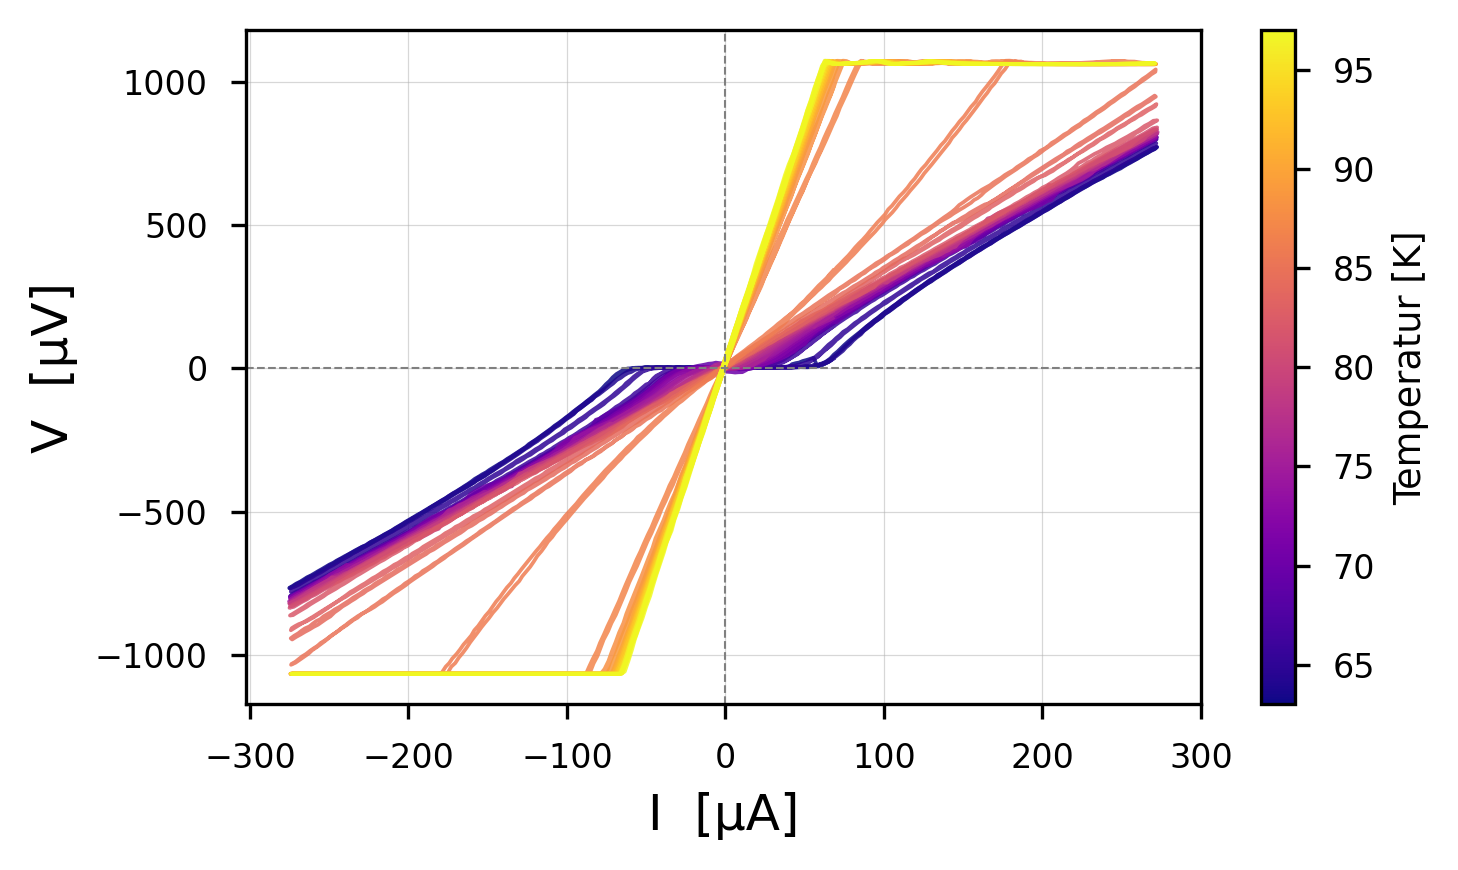

In [38]:
fig, ax = plt.subplots()

cmap   = cm.plasma
norm   = plt.Normalize(vmin=indices[0], vmax=indices[-1])
colors = [cmap(norm(i)) for i in indices]

for idx, color in zip(indices, colors):
    df = files[idx]
    ax.plot(df["I"], df["V"], color=color, linewidth=0.9, alpha=0.85)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Temperatur [K]")

ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel(Y_LABEL, fontsize=12)
#ax.set_title("V-I Kennlinien – alle Temperaturen überlagert", fontsize=13)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.grid(True, linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.savefig("E_Temp_alle_ueberlagert.png", dpi=150)
plt.show()

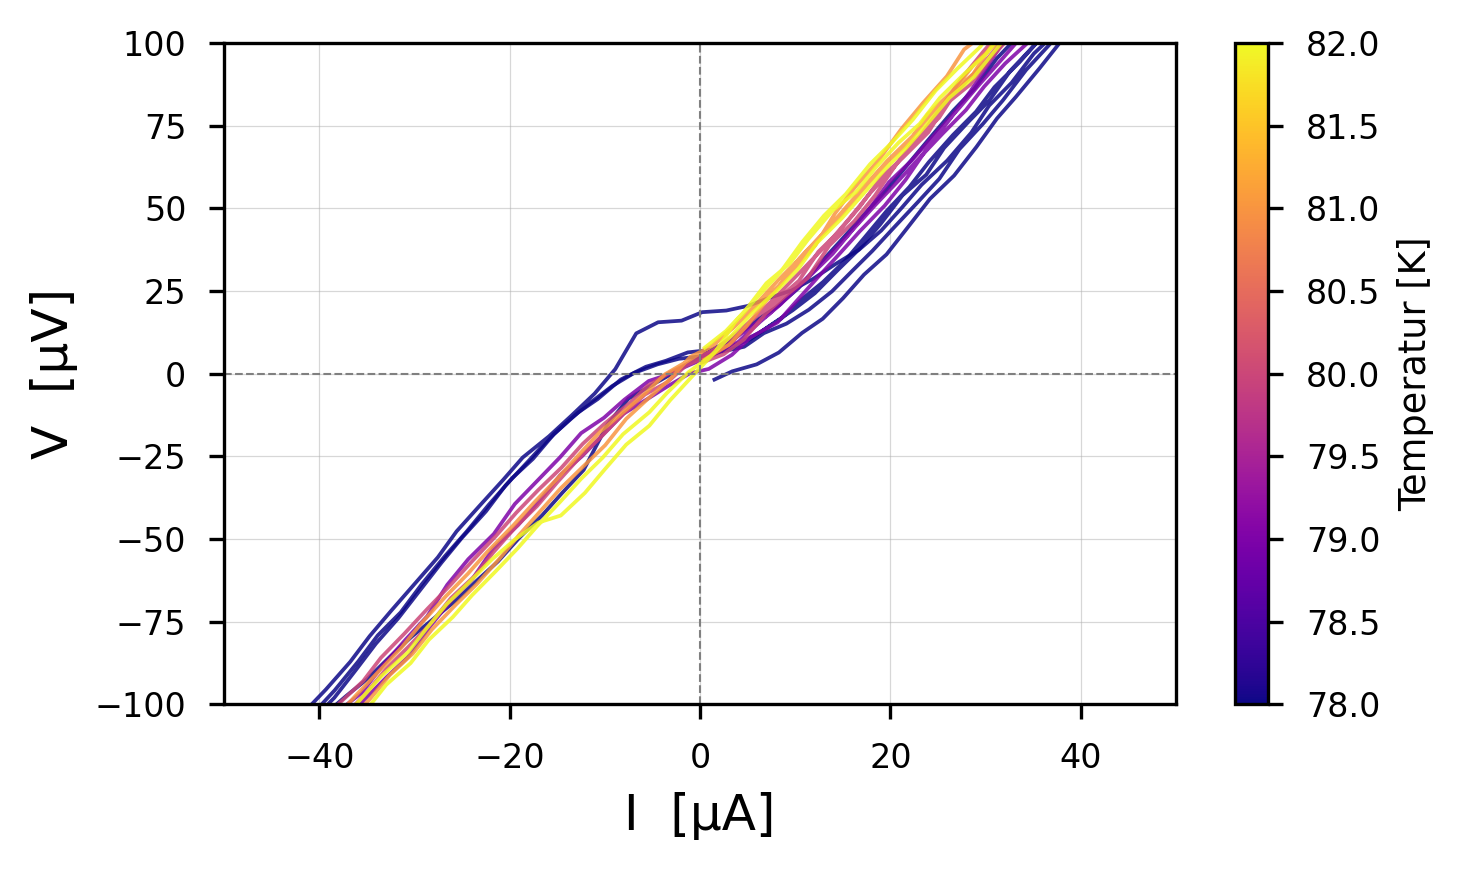

In [39]:
# Mach dass gleiche Plot wie vorhin nur mit den Kiritschen Werten von 91K bis 94K

# Filtere die Indizes für 91K bis 94K (Indizes 91-94)
indices_filtered = [idx for idx in indices if 77 <= idx <= 82]

fig, ax = plt.subplots()

norm_filtered = plt.Normalize(vmin=78, vmax=82)
colors_filtered = [cmap(norm_filtered(i)) for i in indices_filtered]

for idx, color in zip(indices_filtered, colors_filtered):
    df = files[idx]
    ax.plot(df["I"], df["V"], color=color, linewidth=0.9, alpha=0.85, label=f"Index {idx}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_filtered)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Temperatur [K]")

ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel(Y_LABEL, fontsize=12)
#ax.set_title("V-I Kennlinien – 77K bis 82K", fontsize=13)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.grid(True, linewidth=0.3, alpha=0.5)
plt.xlim(-50, 50)
plt.ylim(-100, 100)
#ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("E_Temp_77_82K.png", dpi=150)
plt.show()

## Plot 2 – Einzelne Kurven in einem Grid (kleine Subplots)

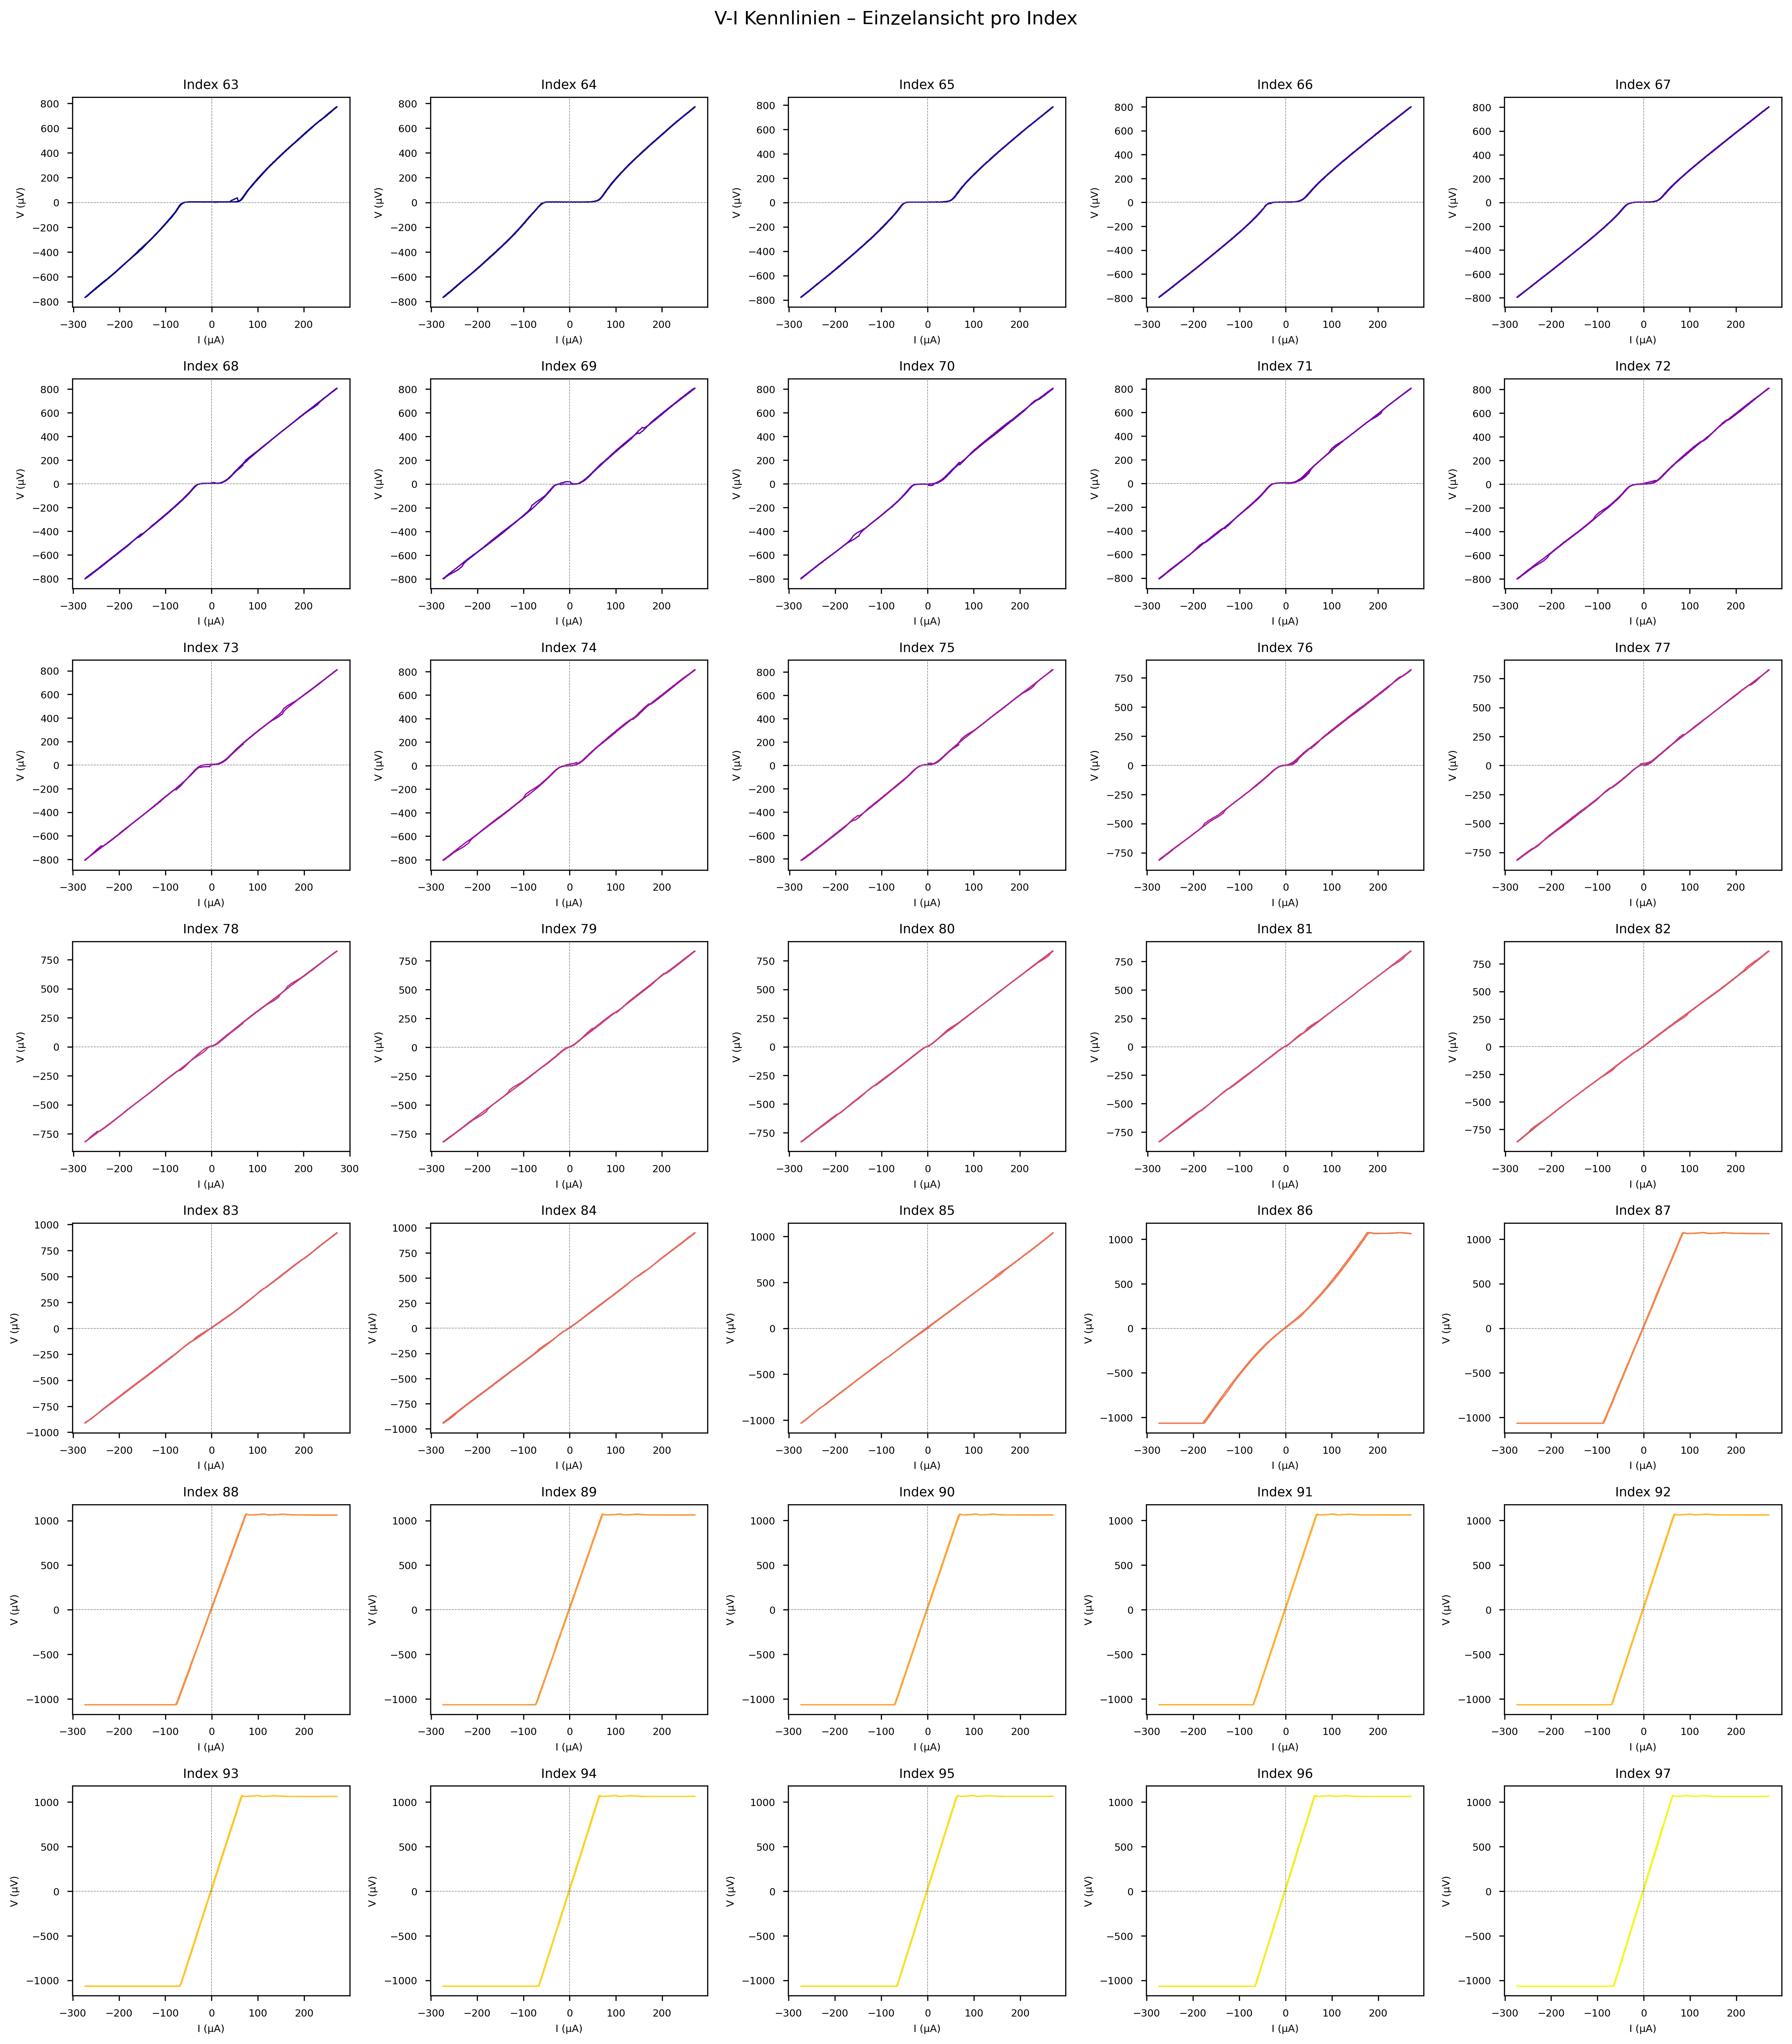

In [40]:
n      = len(indices)
ncols  = 5
nrows  = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3.5, nrows * 2.8),
                         sharex=False, sharey=False)
axes_flat = axes.flatten()

for ax, idx in zip(axes_flat, indices):
    df = files[idx]
    ax.plot(df["I"], df["V"], color=cmap(norm(idx)), linewidth=0.9)
    ax.set_title(f"Index {idx}", fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.tick_params(labelsize=7)
    ax.set_xlabel("I (µA)", fontsize=7)
    ax.set_ylabel("V (µV)", fontsize=7)

# Leere Subplots ausblenden
for ax in axes_flat[len(indices):]:
    ax.set_visible(False)

fig.suptitle("V-I Kennlinien – Einzelansicht pro Index", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("E_Temp_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 3 – Kritischer Strom Ic als Funktion des Index
Ic wird als halbe Breite des flachen Bereichs (|I| bei erstem Spannungsanstieg) geschätzt.

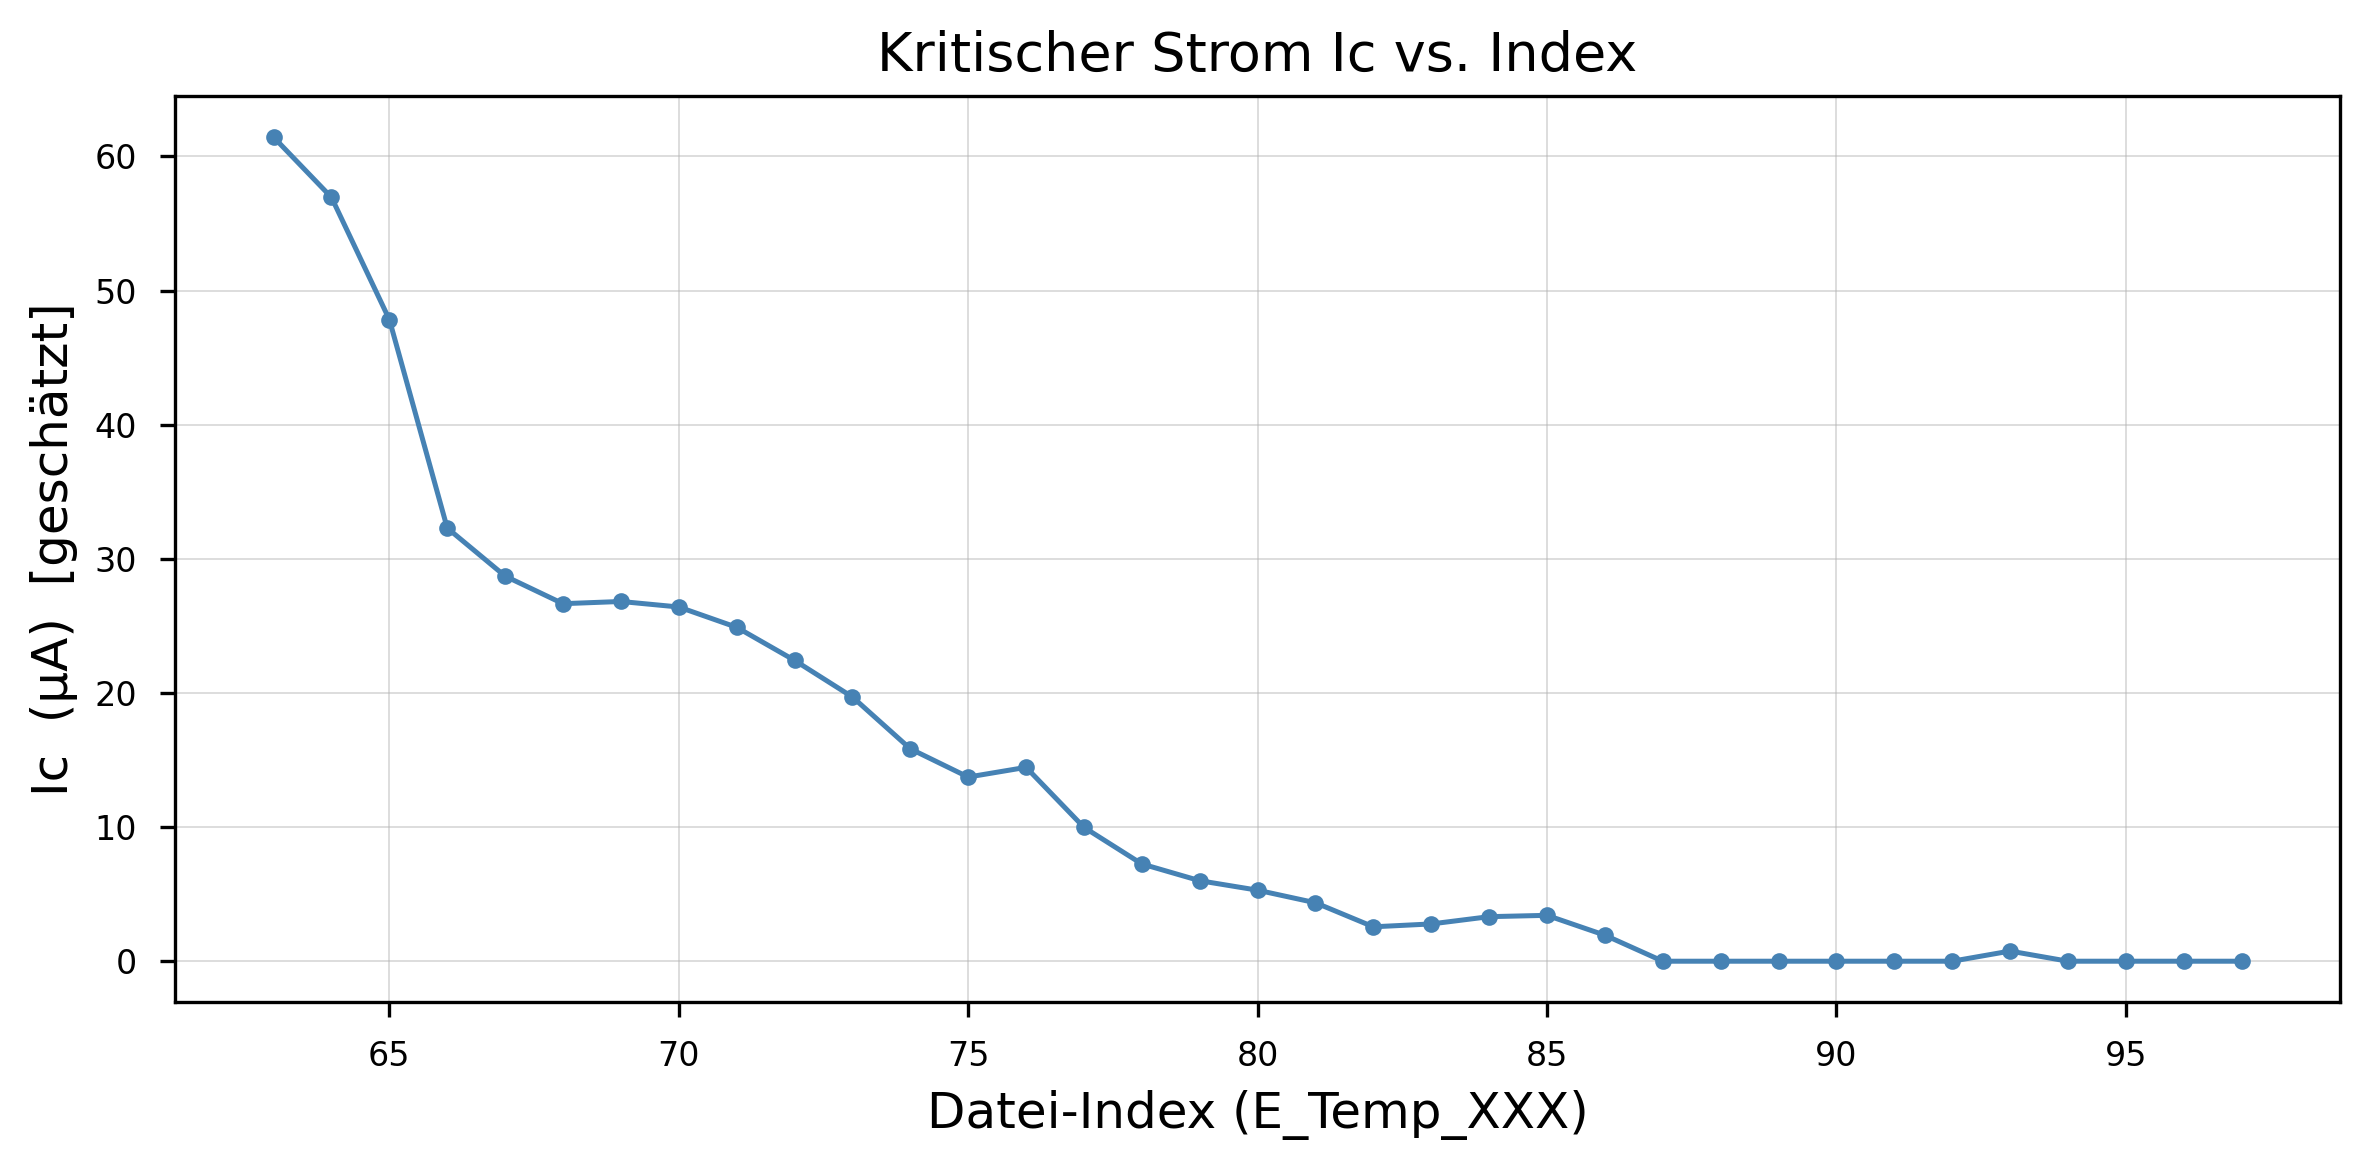

In [41]:
def estimate_Ic(df, threshold_uV=10.0):
    """Schätzt 2*Ic als Breite des Bereichs mit |V| < threshold_uV."""
    flat = df[df["V"].abs() < threshold_uV]
    if flat.empty:
        return np.nan
    return (flat["I"].max() - flat["I"].min()) / 2.0

ic_values = {idx: estimate_Ic(files[idx]) for idx in indices}

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ic_values.keys()), list(ic_values.values()),
        marker="o", markersize=4, linewidth=1.2, color="steelblue")
ax.set_xlabel("Datei-Index (E_Temp_XXX)", fontsize=12)
ax.set_ylabel("Ic  (µA)  [geschätzt]", fontsize=12)
ax.set_title("Kritischer Strom Ic vs. Index", fontsize=13)
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("E_Temp_Ic_vs_index.png", dpi=150)
plt.show()